## Setup and Imports

In [18]:
#  Standard library 
import sys
import os
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

#  Add src/ to Python path 
project_root = Path().resolve().parents[1]
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

#  Data manipulation 
import pandas as pd
import numpy as np

#  Statistics 
# scipy.stats gives us the Kruskal-Wallis test — a non-parametric test
# that checks whether the spend distributions across channels are
# statistically different from each other, without assuming normality
from scipy import stats

#  Visualisation ─
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#  Shared utilities 
from utils.helpers import set_style, save_figure, start_logging
set_style()
log = start_logging(project_root, '03_channel_roi_attribution')

print('All imports successful ✓')
print(f'Project root: {project_root}')

Logging started — 2026-04-16 14:10:34.349933
Log: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Gamezone/gamezone-analytics/logs/03_channel_roi_attribution.txt
All imports successful ✓
Project root: /Users/seleteakpotosu-nartey/Downloads/Data Stuff/Gamezone/gamezone-analytics


## Load Data

In [19]:
processed_path = project_root / 'data' / 'processed'

# Load orders with segment labels (from Notebook 1)
# We use this rather than the raw master because it already has
# the RFM segment label attached to every order


df_raw = pd.read_csv(processed_path / 'orders_with_segments.csv')
df_raw['PURCHASE_TS'] = pd.to_datetime(df_raw['PURCHASE_TS'], errors='coerce')
df_raw['SHIP_TS']     = pd.to_datetime(df_raw['SHIP_TS'],     errors='coerce')
df = df_raw.copy()

rfm_raw = pd.read_csv(processed_path / 'rfm_segments.csv')
rfm = rfm_raw.copy()

print(f'Orders loaded:    {len(df):,}')
print(f'Customers loaded: {len(rfm):,}')
print(f'Null PURCHASE_TS: {df["PURCHASE_TS"].isna().sum():,}')
print(f'Date range:       {df["PURCHASE_TS"].min().date()} → {df["PURCHASE_TS"].max().date()}')
print(f'\nMarketing channels:')
print(df['MARKETING_CHANNEL'].value_counts())

Orders loaded:    21,690
Customers loaded: 19,723
Null PURCHASE_TS: 10,180
Date range:       2019-01-01 → 2021-02-28

Marketing channels:
MARKETING_CHANNEL
direct          17295
email            3239
affiliate         708
social media      319
unknown            46
Name: count, dtype: int64


In [20]:
#  Filter to analysis-ready orders 
# Exclude $0 orders and unknown/null channels
# Unknown channel tells us nothing about which marketing effort drove the purchase

df_analysis = df[
    (df['USD_PRICE'] > 0) &
    (df['MARKETING_CHANNEL'].notna()) &
    (df['MARKETING_CHANNEL'] != 'unknown')
].copy()

print(f'Orders after filtering: {len(df_analysis):,}')
print(f'Channels remaining:     {df_analysis["MARKETING_CHANNEL"].nunique()}')
print(f'\nOrders per channel:')
print(df_analysis['MARKETING_CHANNEL'].value_counts())

Orders after filtering: 21,556
Channels remaining:     4

Orders per channel:
MARKETING_CHANNEL
direct          17294
email            3235
affiliate         708
social media      319
Name: count, dtype: int64


## Channel Volume Analysis

In [21]:
# Order volume and revenue by channel
channel_volume = df_analysis.groupby('MARKETING_CHANNEL').agg(
    order_count      = ('ORDER_ID',   'count'),
    unique_customers = ('USER_ID',    'nunique'),
    total_revenue    = ('USD_PRICE',  'sum'),
    avg_order_value  = ('USD_PRICE',  'mean'),
    median_order_value = ('USD_PRICE','median')
).round(2)

# Add percentage columns
channel_volume['order_share_pct']   = (channel_volume['order_count'] /
                                        channel_volume['order_count'].sum() * 100).round(1)
channel_volume['revenue_share_pct'] = (channel_volume['total_revenue'] /
                                        channel_volume['total_revenue'].sum() * 100).round(1)

# Revenue per customer — this is the first CLV signal
# A channel with fewer customers but higher revenue per customer
# is punching above its weight
channel_volume['revenue_per_customer'] = (
    channel_volume['total_revenue'] / channel_volume['unique_customers']
).round(2)

channel_volume = channel_volume.sort_values('total_revenue', ascending=False)

print('=== Channel Volume & Revenue Summary ===')
print(channel_volume.to_string())

=== Channel Volume & Revenue Summary ===
                   order_count  unique_customers  total_revenue  avg_order_value  median_order_value  order_share_pct  revenue_share_pct  revenue_per_customer
MARKETING_CHANNEL                                                                                                                                             
direct                   17294             15691     5171224.34           299.02              168.00             80.2               85.3                329.57
email                     3235              2966      604818.87           186.96              159.06             15.0               10.0                203.92
affiliate                  708               642      220294.81           311.15              168.00              3.3                3.6                343.14
social media               319               300       69040.33           216.43              168.00              1.5                1.1                230.13


## Channel Value Analysis

In [22]:
# Segment distribution per channel
# This shows what proportion of each channel's customers
# fall into each RFM segment

# We need to work at the customer level here, not the order level
# A customer who placed 3 orders should count once, not three times
# We take the most frequent channel per customer as their acquisition channel
customer_channel = df_analysis.groupby('USER_ID')['MARKETING_CHANNEL'].agg(
    lambda x: x.value_counts().index[0]  # most common channel for this customer
).reset_index()
customer_channel.columns = ['USER_ID', 'primary_channel']

# Merge with RFM segments
customer_channel = customer_channel.merge(
    rfm[['USER_ID', 'segment', 'monetary', 'frequency', 'recency', 'RFM_score']],
    on='USER_ID', how='inner'
)

print(f'Customer-channel table: {len(customer_channel):,} customers')
print(f'\nSegment distribution overall:')
print(customer_channel['segment'].value_counts())

Customer-channel table: 19,599 customers

Segment distribution overall:
segment
At Risk            8529
Lapsed             8047
Champions          1669
Loyal Customers    1354
Name: count, dtype: int64


In [23]:
# Segment mix per channel
# The key metric: what % of each channel's customers are Champions or Loyal?
seg_by_channel = customer_channel.groupby(
    ['primary_channel', 'segment']
).size().unstack(fill_value=0)

# Percentage version
seg_by_channel_pct = seg_by_channel.div(seg_by_channel.sum(axis=1), axis=0) * 100
seg_by_channel_pct = seg_by_channel_pct.round(1)

print('=== Segment mix by channel (% of customers) ===')
print(seg_by_channel_pct.to_string())
print()

# High-value customer rate per channel
# High value = Champions + Loyal Customers combined
high_value_segs = ['Champions', 'Loyal Customers']
available_segs  = [s for s in high_value_segs if s in seg_by_channel_pct.columns]

channel_quality = pd.DataFrame({
    'high_value_customer_pct': seg_by_channel_pct[available_segs].sum(axis=1),
    'total_customers':         seg_by_channel.sum(axis=1)
}).sort_values('high_value_customer_pct', ascending=False)

print('=== High-value customer rate by channel ===')
print('(High value = Champions + Loyal Customers combined)')
print(channel_quality.to_string())

=== Segment mix by channel (% of customers) ===
segment          At Risk  Champions  Lapsed  Loyal Customers
primary_channel                                             
affiliate           38.9        9.0    44.2              7.8
direct              42.7        8.5    41.1              7.7
email               48.7        8.5    40.1              2.8
social media        46.0        6.3    44.3              3.3

=== High-value customer rate by channel ===
(High value = Champions + Loyal Customers combined)
                 high_value_customer_pct  total_customers
primary_channel                                          
affiliate                           16.8              642
direct                              16.2            15691
email                               11.3             2966
social media                         9.6              300


In [24]:
# CLV metrics by channel
# Revenue per customer, avg RFM score, and median spend per channel
channel_clv = customer_channel.groupby('primary_channel').agg(
    customers         = ('USER_ID',    'count'),
    avg_total_spend   = ('monetary',   'mean'),
    median_total_spend= ('monetary',   'median'),
    avg_rfm_score     = ('RFM_score',  'mean'),
    avg_frequency     = ('frequency',  'mean'),
    avg_recency       = ('recency',    'mean')
).round(2).sort_values('avg_total_spend', ascending=False)

print('=== Customer lifetime value metrics by channel ===')
print(channel_clv.to_string())

=== Customer lifetime value metrics by channel ===
                 customers  avg_total_spend  median_total_spend  avg_rfm_score  avg_frequency  avg_recency
primary_channel                                                                                           
affiliate              642           343.14              168.00           2.25           1.10       495.34
direct               15691           329.57              168.00           2.27           1.10       474.20
social media           300           230.13              168.00           2.18           1.06       483.25
email                 2966           203.92              159.74           2.16           1.09       460.59


## Statistical Testing

In [25]:
# Kruskal-Wallis test: do channels produce significantly different spend?
# H0 (null hypothesis): all channels produce customers with the same spend distribution
# H1 (alternative):     at least one channel produces a different spend distribution
# If p < 0.05, we reject H0 — the difference is statistically significant

channel_groups = [
    group['monetary'].values
    for _, group in customer_channel.groupby('primary_channel')
    if len(group) >= 10  # minimum sample size for meaningful test
]

if len(channel_groups) >= 2:
    stat, p_value = stats.kruskal(*channel_groups)
    print('=== Kruskal-Wallis Test: Customer Spend by Channel ===')
    print(f'  Test statistic (H): {stat:.4f}')
    print(f'  p-value:            {p_value:.6f}')
    print()
    if p_value < 0.05:
        print('  RESULT: p < 0.05 → REJECT null hypothesis')
        print('  The differences in customer spend across channels are')
        print('  statistically significant — not due to random chance.')
    else:
        print('  RESULT: p >= 0.05 → FAIL TO REJECT null hypothesis')
        print('  The differences in spend across channels are not')
        print('  statistically significant at the 5% level.')
else:
    print('Insufficient groups for Kruskal-Wallis test')

=== Kruskal-Wallis Test: Customer Spend by Channel ===
  Test statistic (H): 375.5980
  p-value:            0.000000

  RESULT: p < 0.05 → REJECT null hypothesis
  The differences in customer spend across channels are
  statistically significant — not due to random chance.


In [26]:
# Pairwise Mann-Whitney U tests between channels
# Kruskal-Wallis tells us THAT there is a difference somewhere
# Mann-Whitney tells us WHICH pairs of channels differ significantly
# We apply Bonferroni correction to account for multiple comparisons
# (testing 6 pairs inflates false positive rate — Bonferroni divides
# the threshold by the number of tests)

channels = sorted(customer_channel['primary_channel'].unique())
n_tests   = len(channels) * (len(channels) - 1) / 2
bonferroni_threshold = 0.05 / n_tests

print(f'Pairwise Mann-Whitney U tests ({int(n_tests)} pairs)')
print(f'Bonferroni-corrected significance threshold: {bonferroni_threshold:.4f}')
print()
print(f'{"Channel A":<16} {"Channel B":<16} {"Median A":>10} {"Median B":>10} {"p-value":>12} {"Significant?":>14}')
print('-' * 82)

for i, ch_a in enumerate(channels):
    for ch_b in channels[i+1:]:
        group_a = customer_channel[customer_channel['primary_channel'] == ch_a]['monetary']
        group_b = customer_channel[customer_channel['primary_channel'] == ch_b]['monetary']
        if len(group_a) < 5 or len(group_b) < 5:
            continue
        stat, p = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
        sig = 'YES' if p < bonferroni_threshold else 'No'
        print(f'{ch_a:<16} {ch_b:<16} {group_a.median():>10.2f} {group_b.median():>10.2f} {p:>12.6f} {sig:>14}')

Pairwise Mann-Whitney U tests (6 pairs)
Bonferroni-corrected significance threshold: 0.0083

Channel A        Channel B          Median A   Median B      p-value   Significant?
----------------------------------------------------------------------------------
affiliate        direct               168.00     168.00     0.121984             No
affiliate        email                168.00     159.74     0.000000            YES
affiliate        social media         168.00     168.00     0.000346            YES
direct           email                168.00     159.74     0.000000            YES
direct           social media         168.00     168.00     0.003602            YES
email            social media         159.74     168.00     0.000064            YES


## Visualisations

Figure saved → reports/figures/02_03_revenue_vs_customer_share.png


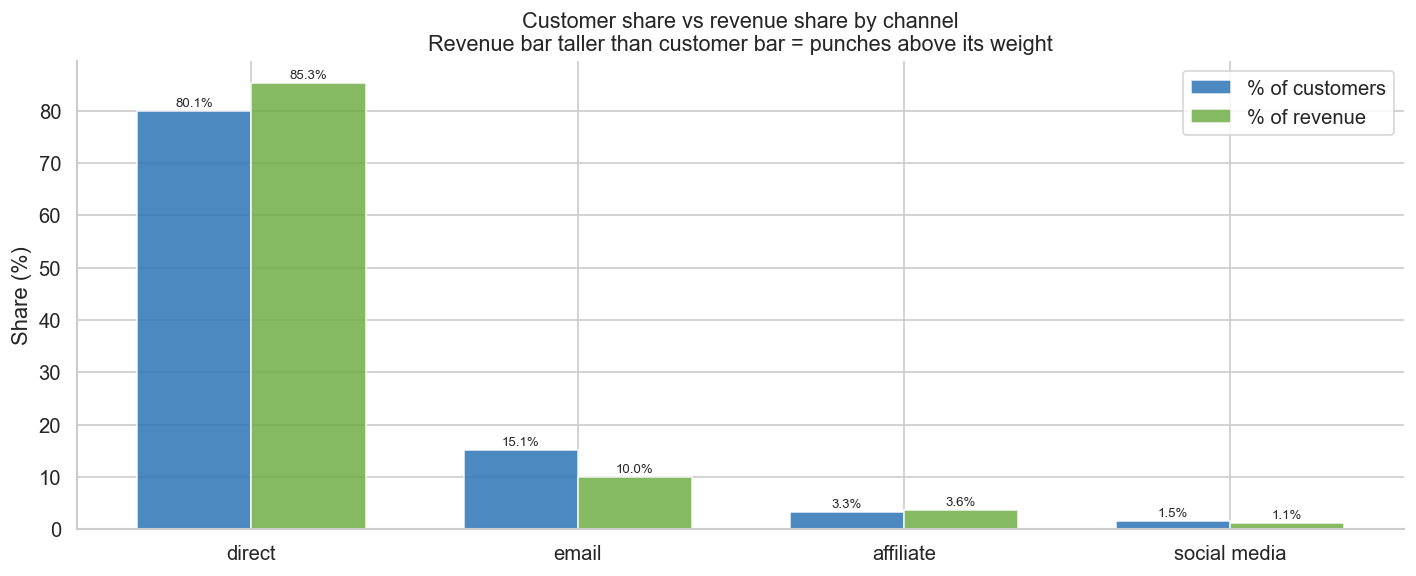

In [27]:
#  Chart 1: Revenue share vs customer share — the ROI gap chart 
# This is the most important chart in the notebook
# If a channel's revenue bar is taller than its customer bar, it is
# producing above-average value customers — it punches above its weight
# If the customer bar is taller, it drives volume but low-value customers

fig, ax = plt.subplots(figsize=(12, 5))

channels_ordered = channel_volume.index.tolist()
x = np.arange(len(channels_ordered))
width = 0.35

customer_shares = [
    customer_channel[customer_channel['primary_channel'] == ch].shape[0] /
    len(customer_channel) * 100
    for ch in channels_ordered
]

revenue_shares = channel_volume['revenue_share_pct'].tolist()

bars1 = ax.bar(x - width/2, customer_shares, width, label='% of customers',
               color='#2E75B6', alpha=0.85)
bars2 = ax.bar(x + width/2, revenue_shares, width, label='% of revenue',
               color='#70AD47', alpha=0.85)

for bar, val in zip(bars1, customer_shares):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, revenue_shares):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(channels_ordered)
ax.set_title('Customer share vs revenue share by channel\n'
             'Revenue bar taller than customer bar = punches above its weight',
             fontsize=13, fontweight='medium')
ax.set_ylabel('Share (%)')
ax.legend()

save_figure(fig, '02_03_revenue_vs_customer_share.png')
plt.show()

Figure saved → reports/figures/02_03_avg_spend_by_channel.png


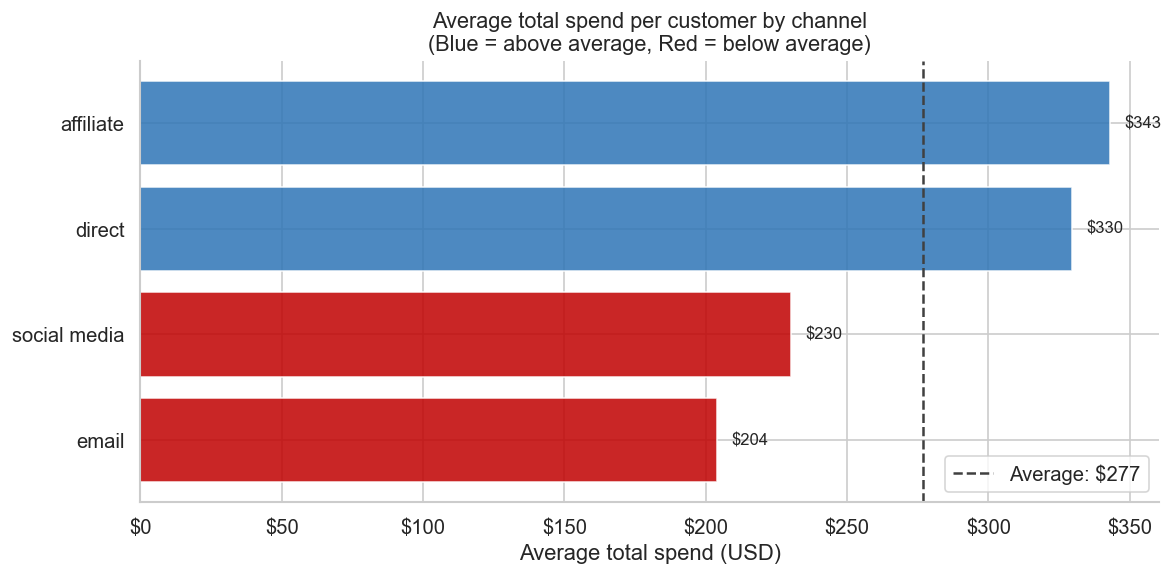

In [28]:
#  Chart 2: Average total spend per customer by channel 
# Revenue per customer is the cleanest single CLV proxy per channel

fig, ax = plt.subplots(figsize=(10, 5))

clv_sorted = channel_clv.sort_values('avg_total_spend', ascending=True)
colors = ['#C00000' if v < channel_clv['avg_total_spend'].mean() else '#2E75B6'
          for v in clv_sorted['avg_total_spend']]

bars = ax.barh(clv_sorted.index, clv_sorted['avg_total_spend'],
               color=colors, alpha=0.85)

avg_line = channel_clv['avg_total_spend'].mean()
ax.axvline(avg_line, color='#404040', linestyle='--', linewidth=1.5,
           label=f'Average: ${avg_line:.0f}')

for bar, val in zip(bars, clv_sorted['avg_total_spend']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10)

ax.set_title('Average total spend per customer by channel\n'
             '(Blue = above average, Red = below average)',
             fontsize=13, fontweight='medium')
ax.set_xlabel('Average total spend (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()

save_figure(fig, '02_03_avg_spend_by_channel.png')
plt.show()

Figure saved → reports/figures/02_03_segment_mix_by_channel.png


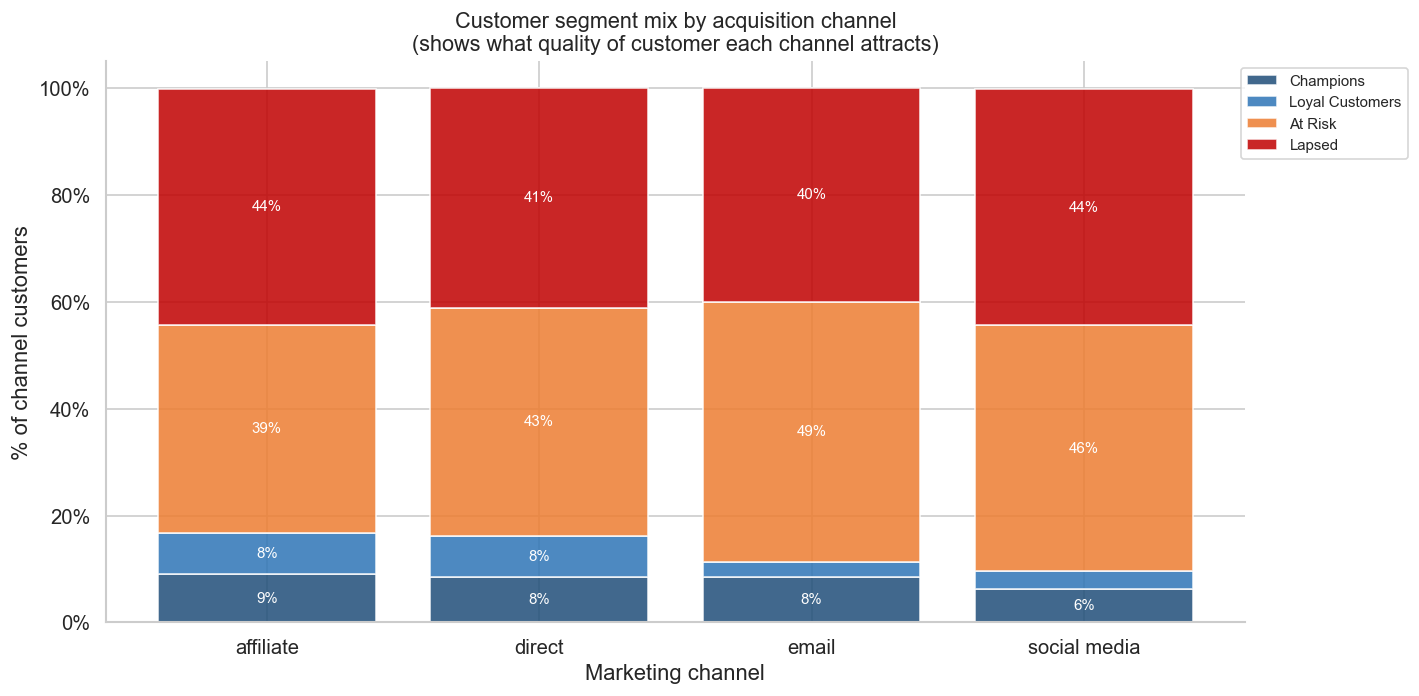

In [29]:
#  Chart 3: Segment mix by channel — stacked bar 
# Shows what kind of customers each channel is acquiring
# A channel dominated by Lapsed customers is not worth investing in

seg_colors_map = {
    'Champions':      '#1F4E79',
    'Loyal Customers':'#2E75B6',
    'At Risk':        '#ED7D31',
    'Lapsed':         '#C00000'
}

# Order segments for stacking
seg_order = ['Champions', 'Loyal Customers', 'At Risk', 'Lapsed']
available  = [s for s in seg_order if s in seg_by_channel_pct.columns]

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(seg_by_channel_pct))
for seg in available:
    vals = seg_by_channel_pct[seg].values
    bars = ax.bar(seg_by_channel_pct.index, vals, bottom=bottom,
                  label=seg, color=seg_colors_map.get(seg, 'grey'), alpha=0.85)
    # Add percentage labels inside bars (only if segment is large enough to fit)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 5:  # only label if slice is > 5% wide
            ax.text(bar.get_x() + bar.get_width()/2,
                    bot + val/2,
                    f'{val:.0f}%',
                    ha='center', va='center',
                    fontsize=9, color='white', fontweight='medium')
    bottom += vals

ax.set_title('Customer segment mix by acquisition channel\n'
             '(shows what quality of customer each channel attracts)',
             fontsize=13, fontweight='medium')
ax.set_ylabel('% of channel customers')
ax.set_xlabel('Marketing channel')
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

save_figure(fig, '02_03_segment_mix_by_channel.png')
plt.show()

Figure saved → reports/figures/02_03_spend_distribution_by_channel.png


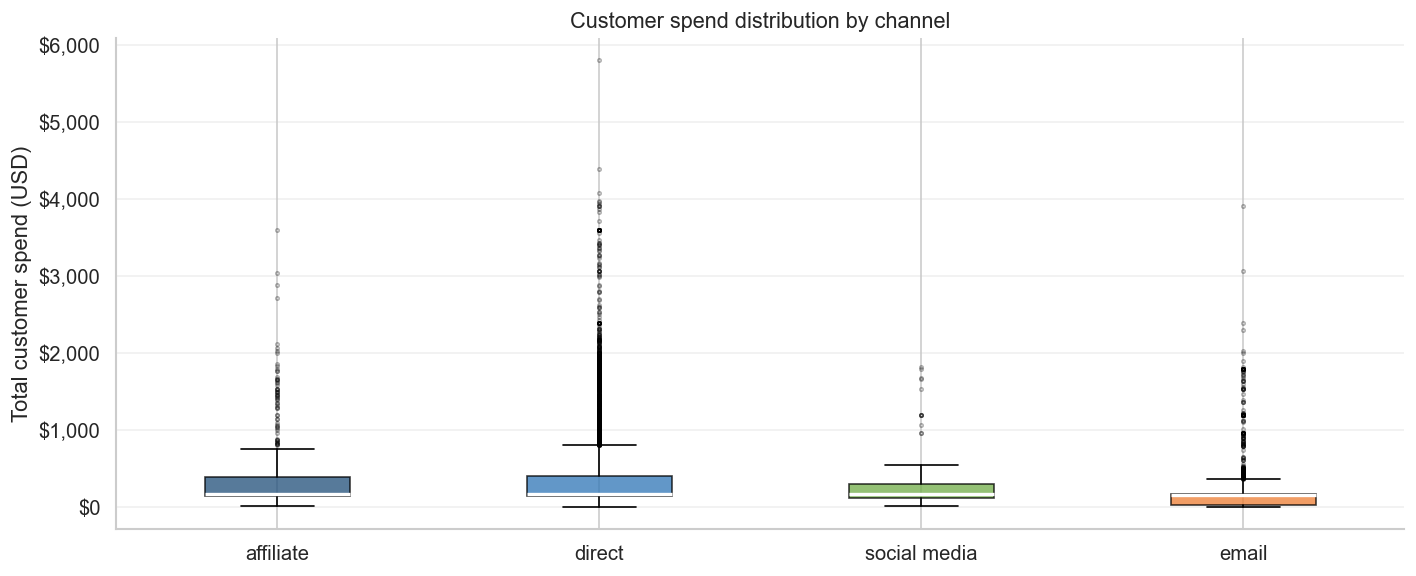

In [30]:
#  Chart 4: Spend distribution by channel — box plots
# Box plots show the full spread of customer spend per channel
# A channel with a high median AND a long upper whisker is ideal —
# consistent mid-level spend with some high-value customers too

fig, ax = plt.subplots(figsize=(12, 5))

channel_order = customer_channel.groupby('primary_channel')['monetary'].median()\
                                .sort_values(ascending=False).index.tolist()

data_for_plot = [customer_channel[customer_channel['primary_channel'] == ch]['monetary'].values
                 for ch in channel_order]

bp = ax.boxplot(data_for_plot, labels=channel_order, patch_artist=True,
                medianprops={'color': 'white', 'linewidth': 2},
                flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})

colors_box = ['#1F4E79', '#2E75B6', '#70AD47', '#ED7D31']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_title('Customer spend distribution by channel',
             fontsize=13, fontweight='medium')
ax.set_ylabel('Total customer spend (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='y', alpha=0.3)

save_figure(fig, '02_03_spend_distribution_by_channel.png')
plt.show()

Figure saved → reports/figures/02_03_channel_roi_scorecard.png


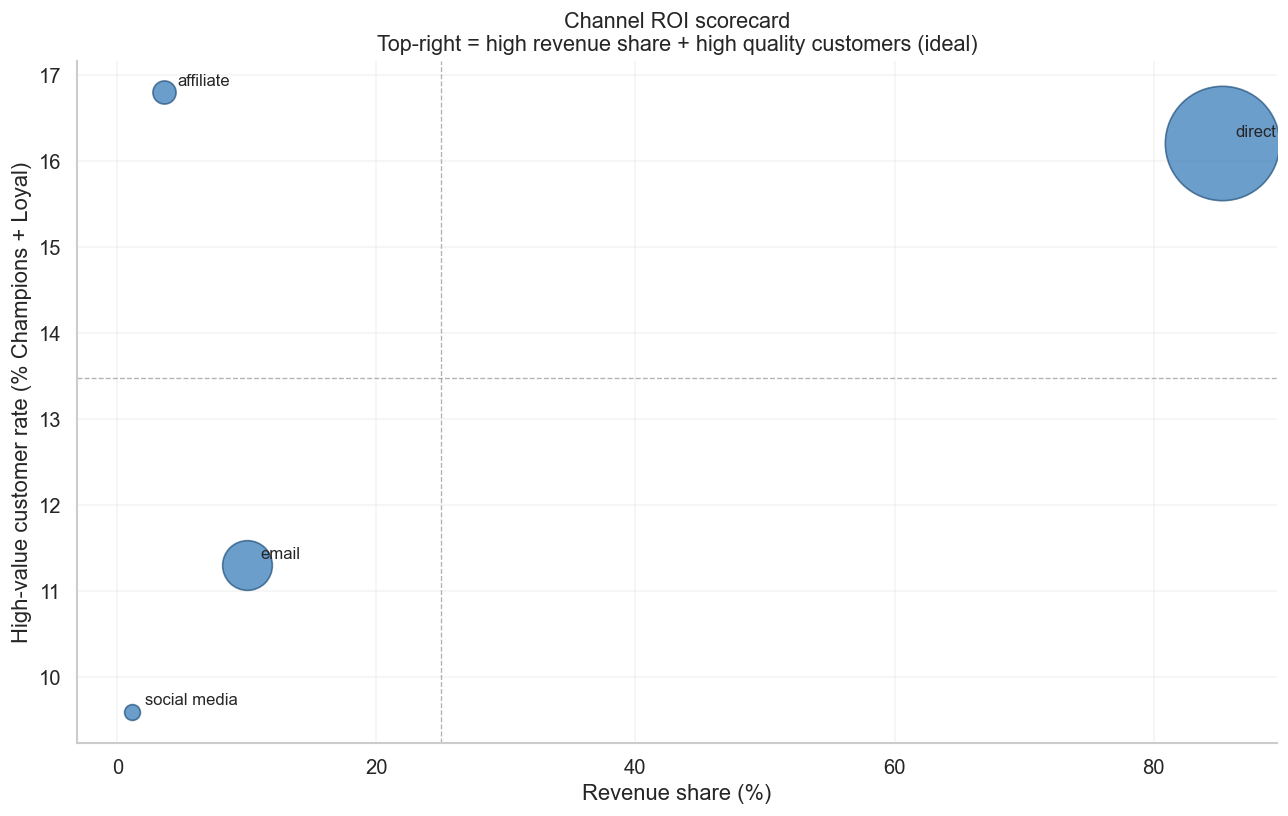

In [31]:
#  Chart 5: Channel ROI scorecard — bubble chart 
# Axes: x = revenue share, y = high-value customer rate
# Bubble size = total customers acquired
# Ideal channel: top-right quadrant (high revenue share + high quality customers)
# Avoid: bottom-right (high revenue share but low quality customers)

fig, ax = plt.subplots(figsize=(11, 7))

for ch in channel_order:
    x_val = channel_volume.loc[ch, 'revenue_share_pct'] if ch in channel_volume.index else 0
    y_val = channel_quality.loc[ch, 'high_value_customer_pct'] if ch in channel_quality.index else 0
    size  = channel_quality.loc[ch, 'total_customers'] if ch in channel_quality.index else 10

    ax.scatter(x_val, y_val, s=size * 0.3, alpha=0.7,
               color='#2E75B6', edgecolors='#1F4E79', linewidths=1)
    ax.annotate(ch, (x_val, y_val),
                textcoords='offset points', xytext=(8, 4), fontsize=10)

# Quadrant lines at mean values
ax.axvline(channel_volume['revenue_share_pct'].mean(),
           color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axhline(channel_quality['high_value_customer_pct'].mean(),
           color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_title('Channel ROI scorecard\n'
             'Top-right = high revenue share + high quality customers (ideal)',
             fontsize=13, fontweight='medium')
ax.set_xlabel('Revenue share (%)')
ax.set_ylabel('High-value customer rate (% Champions + Loyal)')
ax.grid(alpha=0.2)

save_figure(fig, '02_03_channel_roi_scorecard.png')
plt.show()

## Findings and Recommendations

In [32]:
# Build summary table for findings
summary_table = channel_clv[['customers', 'avg_total_spend', 'avg_rfm_score']].copy()
summary_table['revenue_share_pct']       = channel_volume['revenue_share_pct']
summary_table['high_value_customer_pct'] = channel_quality['high_value_customer_pct']
summary_table = summary_table.sort_values('avg_total_spend', ascending=False)

print('=== Channel ROI Attribution — Summary Table ===')
print(summary_table.round(2).to_string())
print()

# Best channel by each metric
best_volume   = channel_volume['order_count'].idxmax()
best_revenue  = channel_volume['total_revenue'].idxmax()
best_spend    = channel_clv['avg_total_spend'].idxmax()
best_quality  = channel_quality['high_value_customer_pct'].idxmax()
best_rfm      = channel_clv['avg_rfm_score'].idxmax()

print('=== Channel Rankings ===')
print(f'Highest order volume:          {best_volume}')
print(f'Highest total revenue:         {best_revenue}')
print(f'Highest avg spend per customer:{best_spend}')
print(f'Highest quality customers:     {best_quality}')
print(f'Highest avg RFM score:         {best_rfm}')

=== Channel ROI Attribution — Summary Table ===
                 customers  avg_total_spend  avg_rfm_score  revenue_share_pct  high_value_customer_pct
primary_channel                                                                                       
affiliate              642           343.14           2.25                3.6                     16.8
direct               15691           329.57           2.27               85.3                     16.2
social media           300           230.13           2.18                1.1                      9.6
email                 2966           203.92           2.16               10.0                     11.3

=== Channel Rankings ===
Highest order volume:          direct
Highest total revenue:         direct
Highest avg spend per customer:affiliate
Highest quality customers:     affiliate
Highest avg RFM score:         direct


In [33]:
print('  NOTEBOOK 3 FINDINGS — CHANNEL ROI ATTRIBUTION')
print()
print('FINDING 1 — Direct channel dominates volume but affiliate')
print('            leads on per-customer value')
print('  Direct drives 80.1% of customers and 85.3% of revenue.')
print('  Its revenue share exceeds its customer share — customers')
print('  acquired via direct spend above average.')
print('  Affiliate has the highest avg spend per customer ($343)')
print('  vs direct ($330), social media ($230), email ($204).')
print()
print('FINDING 2 — Affiliate and direct are statistically equivalent')
print('  Pairwise Mann-Whitney test: affiliate vs direct p=0.122')
print('  (not significant after Bonferroni correction).')
print('  These two channels produce customers of the same quality.')
print('  The difference in scale (642 vs 15,691 customers) is the')
print('  key distinction — affiliate punches at the same weight but')
print('  at far lower volume.')
print()
print('FINDING 3 — Email underperforms on every value metric')
print('  Email represents 15.1% of customers but only 10.0% of')
print('  revenue — its customer bar exceeds its revenue bar,')
print('  meaning email customers systematically underspend.')
print('  Avg spend: $204 (vs $277 overall average).')
print('  Loyal Customer rate: 2.8% — the lowest of any channel,')
print('  roughly 3x lower than affiliate (7.8%) and direct (7.7%).')
print('  Email campaigns appear to attract price-sensitive buyers,')
print('  likely driven by discount and promotional messaging.')
print()
print('FINDING 4 — Social media acquires the lowest quality customers')
print('  Social media has the lowest Champions rate (6.3%) and the')
print('  lowest Loyal Customer rate among known channels (3.3%).')
print('  Combined high-value rate of 9.6% vs affiliate at 16.8%.')
print('  However this is also the smallest channel by volume (319')
print('  orders) so conclusions should be treated with some caution.')
print()
print('FINDING 5 — All channels share the same median spend ($168)')
print('  The Nintendo Switch price point dominates every channel.')
print('  Channel quality differences are driven by the upper tail —')
print('  which channels attract high-ticket buyers (PS5, laptops).')
print('  Affiliate and direct have the longest upper tails.')
print()
print('FINDING 6 — Differences are statistically confirmed')
print('  Kruskal-Wallis H=375.60, p<0.0001.')
print('  5 of 6 channel pairs are significantly different after')
print('  Bonferroni correction. Only affiliate vs direct are')
print('  statistically equivalent.')
print()
print('RECOMMENDATIONS')
print()
print('  1. Scale affiliate channel investment')
print('     Affiliate matches direct on customer quality at $343')
print('     avg spend and 16.8% high-value rate, but operates at')
print('     only 4% of direct volume. Increasing affiliate budget')
print('     is the highest-ROI growth lever available.')
print()
print('  2. Restructure email strategy')
print('     Email attracts the lowest-value customers of any channel.')
print('     Current email approach (likely discount/promo-driven)')
print('     is training price-sensitive behaviour. Test value-led')
print('     content — product launches, loyalty rewards, and')
print('     editorial content — rather than discount campaigns.')
print()
print('  3. Evaluate social media targeting')
print('     Social media has the fewest Champions (6.3%) and Loyal')
print('     Customers (3.3%). Targeting should shift toward high-')
print('     intent audiences (gaming hardware intenders) rather')
print('     than broad reach campaigns.')
print()
print('  4. Protect direct channel customers')
print('     Direct channel customers are high quality (avg $330)')
print('     and represent the majority of revenue. Any changes to')
print('     the direct customer experience carry the highest risk.')
print()
print('Notebook 3 complete ✓')
print('Figures saved     → reports/figures/  (4 charts)')
print('Log saved         → logs/03_channel_roi_attribution.txt')
print('Ready for         → Notebook 4: Geographic CLV Analysis')

  NOTEBOOK 3 FINDINGS — CHANNEL ROI ATTRIBUTION

FINDING 1 — Direct channel dominates volume but affiliate
            leads on per-customer value
  Direct drives 80.1% of customers and 85.3% of revenue.
  Its revenue share exceeds its customer share — customers
  acquired via direct spend above average.
  Affiliate has the highest avg spend per customer ($343)
  vs direct ($330), social media ($230), email ($204).

FINDING 2 — Affiliate and direct are statistically equivalent
  Pairwise Mann-Whitney test: affiliate vs direct p=0.122
  (not significant after Bonferroni correction).
  These two channels produce customers of the same quality.
  The difference in scale (642 vs 15,691 customers) is the
  key distinction — affiliate punches at the same weight but
  at far lower volume.

FINDING 3 — Email underperforms on every value metric
  Email represents 15.1% of customers but only 10.0% of
  revenue — its customer bar exceeds its revenue bar,
  meaning email customers systematically un

## Export

In [34]:
os.makedirs(processed_path, exist_ok=True)

# Export channel CLV summary
channel_output = channel_clv.copy()
channel_output['revenue_share_pct']       = channel_volume['revenue_share_pct']
channel_output['order_share_pct']         = channel_volume['order_share_pct']
channel_output['high_value_customer_pct'] = channel_quality['high_value_customer_pct']

output_path = processed_path / 'channel_roi_summary.csv'
channel_output.to_csv(output_path)

print(f'Exported: channel_roi_summary.csv')
print(f'Rows: {len(channel_output)}')
print()
print(channel_output.round(2).to_string())

Exported: channel_roi_summary.csv
Rows: 4

                 customers  avg_total_spend  median_total_spend  avg_rfm_score  avg_frequency  avg_recency  revenue_share_pct  order_share_pct  high_value_customer_pct
primary_channel                                                                                                                                                        
affiliate              642           343.14              168.00           2.25           1.10       495.34                3.6              3.3                     16.8
direct               15691           329.57              168.00           2.27           1.10       474.20               85.3             80.2                     16.2
social media           300           230.13              168.00           2.18           1.06       483.25                1.1              1.5                      9.6
email                 2966           203.92              159.74           2.16           1.09       460.59           